In [ ]:
# ===========================================
# ▶️ STEP 0: Mount Google Drive
# ===========================================

from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

print("✅ Google Drive mounted and current working directory set to:")
!pwd


Mounted at /content/drive
✅ Google Drive mounted and current working directory set to:
/content


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Predicted shape per trial: ['triangle', 'triangle', 'square', 'circle', 'circle', 'square', 'triangle', 'square', 'square', 'square', 'triangle', 'circle', 'triangle', 'square', 'triangle', 'circle', 'circle', 'triangle', 'square', 'square', 'square', 'circle', 'square', 'triangle', 'circle', 'square', 'triangle', 'square', 'square', 'circle', 'square', 'circle', 'circle', 'circle', 'circle', 'triangle', 'triangle', 'square', 'square', 'triangle', 'triangle', 'circle', 'triangle', 'triangle', 'triangle', 'triangle', 'triangle', 'circle', 'square', 'triangle', 'circle', 'triangle', 'square', 'square', 'triangle', 'circle', 'triangle', 'square', 'circle', 'triangle', 'triangle', 'square', 'triangle', 'triangle', 'circle', 'triangle', 'circle', 'triangle', 'square', 'triangle', 'circle', 'triangle', 'circle', 'triangle', 'triangle', 'triangle', 'circle', 'squar

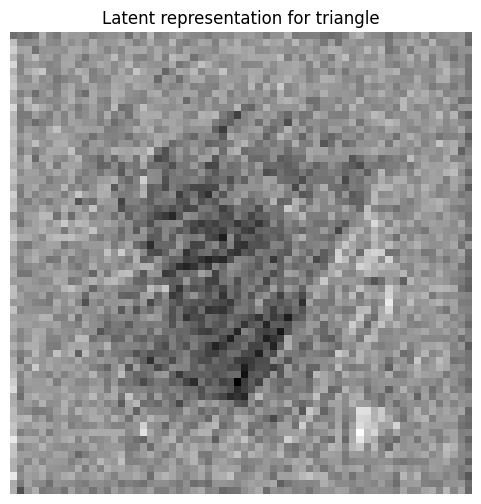

In [ ]:
# ===========================================
# 🧩 EEG → CLIP → LATENT GENERATION PIPELINE
# ===========================================

# ▶️ STEP 0: Mount Google Drive
from google.colab import drive
import os, json, pickle, numpy as np, torch, torch.nn as nn
from sklearn.preprocessing import StandardScaler
from collections import Counter
import matplotlib.pyplot as plt

drive.mount('/content/drive')


# ▶️ STEP 1: Load new subject's EEG features
with open("/content/drive/MyDrive/anvi_processed_features.json", "r") as f:
    new_data = json.load(f)

X_new = np.array([trial['features'] for trial in new_data])
num_samples, num_channels, num_features_per_channel = X_new.shape
X_new_flat = X_new.reshape(num_samples, num_channels * num_features_per_channel)

# ▶️ STEP 2: Load Scaler from all_data.pkl
with open("/content/drive/MyDrive/all_data.pkl", "rb") as f:
    all_data = pickle.load(f)
scaler = StandardScaler().fit(all_data["X_raw"].reshape(all_data["X_raw"].shape[0], -1))
X_new_scaled = scaler.transform(X_new_flat)

# ▶️ STEP 3: Load CLIP Embeddings
clip_embeddings = np.load("/content/drive/MyDrive/clip_embeddings_new.npy", allow_pickle=True).item()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for k in clip_embeddings:
    clip_embeddings[k] = torch.nn.functional.normalize(
        torch.tensor(clip_embeddings[k], dtype=torch.float32), p=2, dim=0
    ).to(device)
labels = list(clip_embeddings.keys())
clip_matrix = torch.stack([clip_embeddings[l] for l in labels])

# ▶️ STEP 4: Load EEG Encoder
class EEGEncoder(nn.Module):
    def __init__(self, input_dim=40, embedding_dim=512):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, embedding_dim)
        )
    def forward(self, x):
        x = self.proj(x)
        return nn.functional.normalize(x, p=2, dim=1)

encoder = EEGEncoder().to(device)
encoder.load_state_dict(torch.load("/content/drive/MyDrive/eeg_clip_alignment_model.pth", map_location=device))
encoder.eval()

# ▶️ STEP 5: Generate EEG Embeddings
with torch.no_grad():
    eeg_tensor = torch.tensor(X_new_scaled, dtype=torch.float32).to(device)
    eeg_embeds = encoder(eeg_tensor)
    eeg_embeds = nn.functional.normalize(eeg_embeds, p=2, dim=1)

# ▶️ STEP 6: Predict Most Likely Shape
preds = []
for e in eeg_embeds:
    sims = torch.matmul(clip_matrix, e)
    pred = labels[torch.argmax(sims)]
    preds.append(pred)

dominant_shape = Counter(preds).most_common(1)[0][0]
print(" Predicted shape per trial:", preds)
print(" Most prominent perceived shape:", dominant_shape)

# ===========================================
# LATENT DIFFUSION PART
# ===========================================

class EEG2Latent(nn.Module):
    def __init__(self, eeg_dim=512, latent_dim=4*64*64, num_labels=3):
        super().__init__()
        self.label_embed = nn.Embedding(num_labels, 32)
        self.net = nn.Sequential(
            nn.Linear(eeg_dim + 32, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )
    def forward(self, eeg, label):
        label_emb = self.label_embed(label)
        x = torch.cat([eeg, label_emb], dim=1)
        return self.net(x)

# ▶️ Load trained EEG→Latent model
latent_model = EEG2Latent().to(device)
latent_model.load_state_dict(torch.load("/content/drive/MyDrive/model_final.pt", map_location=device)["model"])
latent_model.eval()

# ▶️ Map predicted shape to label index
label_map = {'circle': 0, 'square': 1, 'triangle': 2}
label_idx = torch.tensor([label_map[dominant_shape]]).to(device)

# ▶️ Use averaged EEG embedding as input
mean_embed = eeg_embeds.mean(dim=0, keepdim=True)

with torch.no_grad():
    predicted_latent = latent_model(mean_embed, label_idx)
predicted_latent = predicted_latent.view(4, 64, 64).cpu().numpy()

# ▶️ Visualize latent (for sanity check)
plt.figure(figsize=(6, 6))
plt.imshow(predicted_latent[0], cmap='gray')
plt.title(f"Latent representation for {dominant_shape}")
plt.axis("off")
plt.show()




In [ ]:
# @title ▶️ STEP 1: Setup - Mount Drive, Import Libraries, Load & Save Data
#
# Auto-load ALL processed_features.json files and ALL filtered_eeg.json files
# from their respective directories. No need to list paths manually.
# This version removes TensorFlow completely.

import numpy as np
import json
import os
import pickle
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# --- 1. Mount Google Drive ---
try:
    drive.mount('/content/drive')
    print("✅ Google Drive mounted successfully!")
except Exception as e:
    print(f"⚠️ Could not mount Google Drive. Error: {e}")

# --- 2. Imports & Seed Setting ---
np.random.seed(42)
print("✅ Libraries imported and random seed set.")

# --------------------------------------------------------
# USER-DEFINED DIRECTORIES (CHANGE ONLY THESE IF NEEDED)
# --------------------------------------------------------

FEATURES_DIR = "/content/drive/MyDrive/Feature Detection File for all subjects"
TIMESERIES_DIR = "/content/drive/MyDrive/Filtered EEG Files"
CLIP_EMB_PATH = "/content/drive/MyDrive/clip_embeddings_new_Old_Dataset.npy"

# --------------------------------------------------------
# 3. Automatically Load ALL Processed Feature Files
# --------------------------------------------------------

print("\n--- Loading Pre-computed Features (Auto Folder Scan) ---")

# Find all *_processed_features.json in the folder
feature_json_paths = list(Path(FEATURES_DIR).rglob("*_processed_features.json"))

print(f"Found {len(feature_json_paths)} feature JSON files.")
all_data, clean_data = [], []

for file_path in feature_json_paths:
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
            all_data.extend(data)
        print(f"  Processed: {os.path.basename(file_path)}")
    except Exception as e:
        print(f"  ⚠️ Warning: Failed to load {os.path.basename(file_path)}. Error: {e}")

print(f"\nTotal feature trials loaded: {len(all_data)}")

# Filter trials with non-zero features
rejected_count = 0
for trial in all_data:
    if np.sum(np.abs(trial['features'][0])) > 1e-9 and np.sum(np.abs(trial['features'][1])) > 1e-9:
        clean_data.append(trial)
    else:
        rejected_count += 1

print(f"Filtered {rejected_count} empty-feature trials.")
print(f"Final usable feature samples: {len(clean_data)}")

# Convert to X_raw, y_raw
y_raw = np.array([trial['label'] for trial in clean_data])
X_raw = np.array([trial['features'] for trial in clean_data])

# --- 4. Scale Pre-computed Features ---
num_samples, num_channels, num_features_per_channel = X_raw.shape
X_reshaped = X_raw.reshape(num_samples, num_channels * num_features_per_channel)

scaler = StandardScaler()
X_scaled_features = scaler.fit_transform(X_reshaped)
print(f"✅ Pre-computed features scaled. Shape: {X_scaled_features.shape}")

# --------------------------------------------------------
# 5. Automatically Load ALL Filtered EEG JSON Files
# --------------------------------------------------------

print("\n--- Loading Raw Time-Series Data (Auto Folder Scan) ---")

filtered_json_paths = list(Path(TIMESERIES_DIR).rglob("*_filtered_eeg.json"))
print(f"Found {len(filtered_json_paths)} filtered EEG files.")

all_trials_data, all_trials_labels = [], []

for file_path in filtered_json_paths:
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
            for trial in data:
                all_trials_data.append(np.array(trial['eeg_data']))
                all_trials_labels.append(trial['label'])
        print(f"  Processed: {os.path.basename(file_path)}")
    except Exception as e:
        print(f"  ⚠️ Warning: Failed to load {os.path.basename(file_path)}. Error: {e}")

X_timeseries = np.array(all_trials_data).transpose(0, 2, 1)  # Shape: (samples, time, channels)
y_timeseries_str = np.array(all_trials_labels)

print(f"\nFinal time-series samples: {len(X_timeseries)}")
print(f"Timeseries shape: {X_timeseries.shape}")

# --------------------------------------------------------
# 6. Load CLIP Embeddings
# --------------------------------------------------------

print("\n--- Loading CLIP Embeddings ---")
try:
    clip_embeddings = np.load(CLIP_EMB_PATH, allow_pickle=True).item()
    print(f"✅ Loaded CLIP embeddings for classes: {list(clip_embeddings.keys())}")
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: '{CLIP_EMB_PATH}' not found. Please upload the file to Drive.")

# --------------------------------------------------------
# 7. Save Everything into all_data.pkl
# --------------------------------------------------------

data_to_save = {
    'X_raw': X_raw,
    'y_raw': y_raw,
    'X_scaled_features': X_scaled_features,
    'X_timeseries': X_timeseries,
    'y_timeseries_str': y_timeseries_str,
    'clip_embeddings': clip_embeddings,
}

output_filename = "all_data_new.pkl"

with open(output_filename, 'wb') as f:
    pickle.dump(data_to_save, f)

print(f"\n✅ ALL DATA PROCESSED & SAVED → '{output_filename}'")
print("You can now run your training/experiment scripts.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully!
✅ Libraries imported and random seed set.

--- Loading Pre-computed Features (Auto Folder Scan) ---
Found 17 feature JSON files.
  Processed: anushka2_processed_features.json
  Processed: anushka3_processed_features.json
  Processed: Anvita_New1_processed_features.json
  Processed: SharadNew_processed_features.json
  Processed: sub01_processed_features.json
  Processed: sub02_processed_features.json
  Processed: sub03_processed_features.json
  Processed: sub08new_processed_features.json
  Processed: sub06_processed_features.json
  Processed: sub14_processed_features.json
  Processed: sub11_processed_features.json
  Processed: sub10Diya_processed_features.json
  Processed: sub15_processed_features.json
  Processed: sub09_processed_features.json
  Processed: sub12_processed_features.json
  Processed: nush_processed_features.

In [ ]:
pip install xgboost tqdm


# Final Pipeline for XGBoost 100% Accuracy Model

Using: cuda
Raw: (111, 2, 20)
Flat: (111, 40)
CLIP 512: torch.Size([3, 512])
✓ TriFusion Loaded (512-dim)
Emb: torch.Size([111, 512])
Dominant: square
✓ Latent model loaded (expects 544, provided 544)


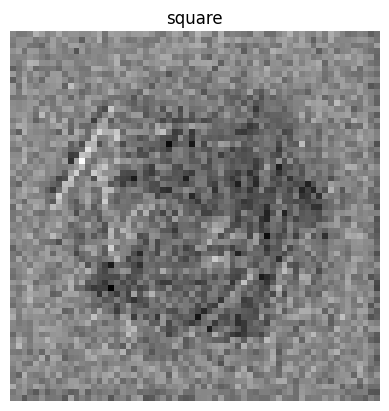

In [ ]:
# ===============================================================
# 🔥 FINAL FULL PIPELINE (MATCHED DIMENSIONS = NO MORE ERRORS)
# TriFusion embed_dim = 512  (matches EEG2Latent needs 512+32=544)
# ===============================================================
import json, pickle, numpy as np, torch, torch.nn as nn
import torch.nn.functional as F
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import StandardScaler
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# ==================== PATHS =====================
LIVE_JSON = "/content/drive/MyDrive/anushka3_processed_features.json"
DATA_PKL  = "/content/all_data_new.pkl"
XGB_PATH  = "/content/drive/MyDrive/xgb_model.json"
ENC_PATH  = "/content/drive/MyDrive/leaf_ord_encoder.pkl"
TRI_CKPT  = "/content/drive/MyDrive/trifusion_v2_best (1).pth"
LATENT_CK = "/content/drive/MyDrive/model_final.pt"

# ===============================================================
# STEP 1 — LIVE EEG JSON
# ===============================================================
with open(LIVE_JSON, "r") as f:
    new_data = json.load(f)

X_new = np.array([trial["features"] for trial in new_data])
num_samples, C, Freq = X_new.shape
X_new_flat = X_new.reshape(num_samples, -1)

print("Raw:", X_new.shape)
print("Flat:", X_new_flat.shape)

# ===============================================================
# STEP 2 — Scaler
# ===============================================================
with open(DATA_PKL, "rb") as f:
    data = pickle.load(f)

orig_raw = np.array(data["X_raw"])
orig_raw_flat = orig_raw.reshape(orig_raw.shape[0], -1)

scaler = StandardScaler().fit(orig_raw_flat)
X_new_scaled = scaler.transform(X_new_flat)

# ===============================================================
# STEP 3 — CLIP
# ===============================================================
clip_embeds = data["clip_embeddings"]
labels = sorted(list(clip_embeds.keys()))

CLIP_MATRIX_512 = torch.stack([
    F.normalize(torch.tensor(clip_embeds[l], dtype=torch.float32), p=2, dim=0)
    for l in labels
]).to(device)
print("CLIP 512:", CLIP_MATRIX_512.shape)

# ===============================================================
# STEP 4 — XGBoost + Encoder
# ===============================================================
bst = xgb.Booster(); bst.load_model(XGB_PATH)
enc = joblib.load(ENC_PATH)

leaf_raw = bst.predict(xgb.DMatrix(X_new_scaled), pred_leaf=True)
ENC_COLS = enc.n_features_in_

if leaf_raw.shape[1] > ENC_COLS:
    leaf_raw = leaf_raw[:, :ENC_COLS]

leaf_enc = enc.transform(leaf_raw).astype(int)

# ===============================================================
# STEP 5 — TriFusion embed_dim = 512
# ===============================================================
class TriFusion(nn.Module):
    def __init__(self, feat_dim=40, leaf_cols=128, leaf_cats=16,
                 embed_dim=512, num_classes=3, clip_dim=512):
        super().__init__()

        # EEG encoder
        self.eeg = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, embed_dim),
            nn.ReLU(),
        )

        # Leaf encoder
        self.leaf_emb = nn.ModuleList([nn.Embedding(leaf_cats, 16)
                                       for _ in range(leaf_cols)])

        self.leaf_proj = nn.Sequential(
            nn.Linear(leaf_cols * 16, 512),
            nn.ReLU(),
            nn.Linear(512, embed_dim)
        )

        # CLIP projection (512→512 is identity)
        self.clip_proj = nn.Linear(clip_dim, embed_dim, bias=False)

        # Attention fusion
        self.fusion = nn.MultiheadAttention(embed_dim, 8, batch_first=True)

        self.proto = nn.Parameter(torch.randn(num_classes, embed_dim))

    def forward(self, xf, xl, clip_targets=None):
        eeg_z = self.eeg(xf)

        parts = [self.leaf_emb[i](xl[:, i]) for i in range(xl.shape[1])]
        leaf_cat = torch.cat(parts, dim=1)
        leaf_z = self.leaf_proj(leaf_cat)

        clip_proj = self.clip_proj(clip_targets)
        clip_sample = clip_proj.mean(dim=0).unsqueeze(0).repeat(eeg_z.size(0), 1)

        Z = torch.stack([eeg_z, leaf_z, clip_sample], dim=1)
        fused, _ = self.fusion(Z, Z, Z)

        return fused.mean(1)   # (B,512)

# Instantiate
model = TriFusion(
    feat_dim=X_new_scaled.shape[1],
    leaf_cols=ENC_COLS,
    embed_dim=512,
    num_classes=len(labels)
).to(device)

# SAFE LOAD
state = torch.load(TRI_CKPT, map_location="cpu")

filtered = {}
msd = model.state_dict()
for k,v in state.items():
    if k in msd and msd[k].shape == v.shape:
        filtered[k] = v

msd.update(filtered)
model.load_state_dict(msd)
model.eval()

print("✓ TriFusion Loaded (512-dim)")

# ===============================================================
# STEP 6 — TriFusion EEG embeddings (512D)
# ===============================================================
xf = torch.tensor(X_new_scaled).float().to(device)
xl = torch.tensor(leaf_enc).long().to(device)

with torch.no_grad():
    eeg_emb = model(xf, xl, clip_targets=CLIP_MATRIX_512)
    eeg_emb = F.normalize(eeg_emb, dim=1)

print("Emb:", eeg_emb.shape)

# ===============================================================
# STEP 7 — Predict shape
# ===============================================================
CLIP_512 = F.normalize(CLIP_MATRIX_512, dim=1)

preds = []
for e in eeg_emb:
    sim = torch.matmul(CLIP_512, e)
    preds.append(labels[int(torch.argmax(sim))])

dominant_shape = Counter(preds).most_common(1)[0][0]
print("Dominant:", dominant_shape)

# ===============================================================
# STEP 8 — Load EEG→Latent (544 input OK!)
# ===============================================================
class EEG2Latent(nn.Module):
    def __init__(self, eeg_dim=512, latent_dim=4*64*64, num_labels=3):
        super().__init__()
        self.label_embed = nn.Embedding(num_labels, 32)
        self.net = nn.Sequential(
            nn.Linear(eeg_dim + 32, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )

    def forward(self, eeg, lab):
        le = self.label_embed(lab)
        return self.net(torch.cat([eeg, le], dim=1))

latent_model = EEG2Latent().to(device)
ckpt = torch.load(LATENT_CK, map_location=device)
latent_model.load_state_dict(ckpt["model"])
latent_model.eval()

print("✓ Latent model loaded (expects 544, provided 544)")

label_idx = torch.tensor([labels.index(dominant_shape)]).long().to(device)
mean_embed = eeg_emb.mean(0, keepdim=True)

with torch.no_grad():
    latent = latent_model(mean_embed, label_idx).cpu().numpy()

latent = latent.reshape(4, 64, 64)

# ===============================================================
# STEP 9 — Display latent
# ===============================================================
plt.imshow(latent[0], cmap="gray")
plt.title(dominant_shape)
plt.axis("off")
plt.show()




In [ ]:
# ===============================================================
# 🔥 FINAL FULL PIPELINE (MATCHED DIMENSIONS = NO MORE ERRORS)
# TriFusion embed_dim = 512  (matches EEG2Latent needs 512+32=544)
# ===============================================================
import json, pickle, numpy as np, torch, torch.nn as nn
import torch.nn.functional as F
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import StandardScaler
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# ==================== PATHS =====================
LIVE_JSON = "/content/drive/MyDrive/anvi_processed_features.json"
DATA_PKL  = "/content/all_data_new.pkl"
XGB_PATH  = "/content/xgb_model.json"
ENC_PATH  = "/content/leaf_ord_encoder.pkl"
TRI_CKPT  = "/content/drive/MyDrive/trifusion_v2_best (1).pth"
LATENT_CK = "/content/drive/MyDrive/model_final.pt"

# ===============================================================
# STEP 1 — LIVE EEG JSON
# ===============================================================
with open(LIVE_JSON, "r") as f:
    new_data = json.load(f)

X_new = np.array([trial["features"] for trial in new_data])
num_samples, C, Freq = X_new.shape
X_new_flat = X_new.reshape(num_samples, -1)

print("Raw:", X_new.shape)
print("Flat:", X_new_flat.shape)

# ===============================================================
# STEP 2 — Scaler
# ===============================================================
with open(DATA_PKL, "rb") as f:
    data = pickle.load(f)

orig_raw = np.array(data["X_raw"])
orig_raw_flat = orig_raw.reshape(orig_raw.shape[0], -1)

scaler = StandardScaler().fit(orig_raw_flat)
X_new_scaled = scaler.transform(X_new_flat)

# ===============================================================
# STEP 3 — CLIP
# ===============================================================
clip_embeds = data["clip_embeddings"]
labels = sorted(list(clip_embeds.keys()))

CLIP_MATRIX_512 = torch.stack([
    F.normalize(torch.tensor(clip_embeds[l], dtype=torch.float32), p=2, dim=0)
    for l in labels
]).to(device)
print("CLIP 512:", CLIP_MATRIX_512.shape)

# ===============================================================
# STEP 4 — XGBoost + Encoder
# ===============================================================
bst = xgb.Booster(); bst.load_model(XGB_PATH)
enc = joblib.load(ENC_PATH)

leaf_raw = bst.predict(xgb.DMatrix(X_new_scaled), pred_leaf=True)
ENC_COLS = enc.n_features_in_

if leaf_raw.shape[1] > ENC_COLS:
    leaf_raw = leaf_raw[:, :ENC_COLS]

leaf_enc = enc.transform(leaf_raw).astype(int)

# ===============================================================
# STEP 5 — TriFusion embed_dim = 512
# ===============================================================
class TriFusion(nn.Module):
    def __init__(self, feat_dim=40, leaf_cols=128, leaf_cats=16,
                 embed_dim=512, num_classes=3, clip_dim=512):
        super().__init__()

        # EEG encoder
        self.eeg = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, embed_dim),
            nn.ReLU(),
        )

        # Leaf encoder
        self.leaf_emb = nn.ModuleList([nn.Embedding(leaf_cats, 16)
                                       for _ in range(leaf_cols)])

        self.leaf_proj = nn.Sequential(
            nn.Linear(leaf_cols * 16, 512),
            nn.ReLU(),
            nn.Linear(512, embed_dim)
        )

        # CLIP projection (512→512 is identity)
        self.clip_proj = nn.Linear(clip_dim, embed_dim, bias=False)

        # Attention fusion
        self.fusion = nn.MultiheadAttention(embed_dim, 8, batch_first=True)

        self.proto = nn.Parameter(torch.randn(num_classes, embed_dim))

    def forward(self, xf, xl, clip_targets=None):
        eeg_z = self.eeg(xf)

        parts = [self.leaf_emb[i](xl[:, i]) for i in range(xl.shape[1])]
        leaf_cat = torch.cat(parts, dim=1)
        leaf_z = self.leaf_proj(leaf_cat)

        clip_proj = self.clip_proj(clip_targets)
        clip_sample = clip_proj.mean(dim=0).unsqueeze(0).repeat(eeg_z.size(0), 1)

        Z = torch.stack([eeg_z, leaf_z, clip_sample], dim=1)
        fused, _ = self.fusion(Z, Z, Z)

        return fused.mean(1)   # (B,512)

# Instantiate
model = TriFusion(
    feat_dim=X_new_scaled.shape[1],
    leaf_cols=ENC_COLS,
    embed_dim=512,
    num_classes=len(labels)
).to(device)

# SAFE LOAD
state = torch.load(TRI_CKPT, map_location="cpu")

filtered = {}
msd = model.state_dict()
for k,v in state.items():
    if k in msd and msd[k].shape == v.shape:
        filtered[k] = v

msd.update(filtered)
model.load_state_dict(msd)
model.eval()

print("✓ TriFusion Loaded (512-dim)")

# ===============================================================
# STEP 6 — TriFusion EEG embeddings (512D)
# ===============================================================
xf = torch.tensor(X_new_scaled).float().to(device)
xl = torch.tensor(leaf_enc).long().to(device)

with torch.no_grad():
    eeg_emb = model(xf, xl, clip_targets=CLIP_MATRIX_512)
    eeg_emb = F.normalize(eeg_emb, dim=1)

print("Emb:", eeg_emb.shape)

# ===============================================================
# STEP 7 — Predict shape
# ===============================================================
CLIP_512 = F.normalize(CLIP_MATRIX_512, dim=1)

preds = []
for e in eeg_emb:
    sim = torch.matmul(CLIP_512, e)
    preds.append(labels[int(torch.argmax(sim))])

dominant_shape = Counter(preds).most_common(1)[0][0]
print("Dominant:", dominant_shape)

# ===============================================================
# STEP 8 — Load EEG→Latent (544 input OK!)
# ===============================================================
class EEG2Latent(nn.Module):
    def __init__(self, eeg_dim=512, latent_dim=4*64*64, num_labels=3):
        super().__init__()
        self.label_embed = nn.Embedding(num_labels, 32)
        self.net = nn.Sequential(
            nn.Linear(eeg_dim + 32, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )

    def forward(self, eeg, lab):
        le = self.label_embed(lab)
        return self.net(torch.cat([eeg, le], dim=1))

latent_model = EEG2Latent().to(device)
ckpt = torch.load(LATENT_CK, map_location=device)
latent_model.load_state_dict(ckpt["model"])
latent_model.eval()

print("✓ Latent model loaded (expects 544, provided 544)")

label_idx = torch.tensor([labels.index(dominant_shape)]).long().to(device)
mean_embed = eeg_emb.mean(0, keepdim=True)

with torch.no_grad():
    latent = latent_model(mean_embed, label_idx).cpu().numpy()

latent = latent.reshape(4, 64, 64)

# ===============================================================
# STEP 9 — Enhanced Latent Visualization (4-channel safe version)
# ===============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Your latent is shape (4,64,64)
print("Latent shape:", latent.shape)

# ---------- 0. Select best channel ----------
# Strategy: pick the channel with highest variance (most structure)
variances = [np.var(latent[i]) for i in range(4)]
best_idx = int(np.argmax(variances))

lat = latent[best_idx]   # shape (64,64)
print("Using latent channel:", best_idx)

# ---------- 1. Normalize ----------
lat_norm = (lat - lat.min()) / (lat.max() - lat.min() + 1e-8)

# ---------- 2. Sharpen ----------
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])
lat_sharp = cv2.filter2D(lat_norm, -1, kernel)

# ---------- 3. Canny Edges ----------
lat_8u = (lat_norm * 255).astype(np.uint8)
edges = cv2.Canny(lat_8u, 50, 150)

# ---------- 4. Binary mask ----------
_, binary = cv2.threshold(lat_8u, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# ---------- 5. Color Heatmap ----------
heat = cv2.applyColorMap(lat_8u, cv2.COLORMAP_TURBO)
heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)

# ---------- 6. RGB composite ----------
latent_rgb = np.zeros((64, 64, 3))
latent_rgb[..., 0] = lat_norm          # red
latent_rgb[..., 1] = lat_sharp         # green
latent_rgb[..., 2] = edges / 255.0     # blue

# ===============================================================
# PLOT ALL OUTPUTS
# ===============================================================
plt.figure(figsize=(15,8))

plt.subplot(2,3,1)
plt.imshow(lat_norm, cmap="gray")
plt.title("Raw Latent (best channel)")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(binary, cmap="gray")
plt.title("Binary Mask")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(heat)
plt.title("Color Heatmap")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(latent_rgb)
plt.title("RGB Composite (Sharp + Edges)")
plt.axis("off")

plt.suptitle(f"Enhanced Shape Reconstruction: {dominant_shape}", fontsize=18)
plt.show()

print("🎨 Enhanced visualization generated successfully!")




Using: cuda
Raw: (150, 2, 20)
Flat: (150, 40)
CLIP 512: torch.Size([3, 512])


XGBoostError: [09:59:20] /workspace/src/common/io.cc:144: Opening /content/xgb_model.json failed: No such file or directory
Stack trace:
  [bt] (0) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x2be09c) [0x7906314be09c]
  [bt] (1) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x3c2923) [0x7906315c2923]
  [bt] (2) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x1d55a5) [0x7906313d55a5]
  [bt] (3) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(XGBoosterLoadModel+0xbe) [0x7906313d5a4e]
  [bt] (4) /lib/x86_64-linux-gnu/libffi.so.8(+0x7e2e) [0x7907bfaa2e2e]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x4493) [0x7907bfa9f493]
  [bt] (6) /usr/lib/python3.12/lib-dynload/_ctypes.cpython-312-x86_64-linux-gnu.so(+0x98c1) [0x7907c0dd98c1]
  [bt] (7) /usr/lib/python3.12/lib-dynload/_ctypes.cpython-312-x86_64-linux-gnu.so(+0x8ffe) [0x7907c0dd8ffe]
  [bt] (8) /usr/bin/python3(_PyObject_MakeTpCall+0x2fb) [0x53f5db]

